# RetailRocket Dataset — Exploratory Data Analysis

**Goal:** understand the three CSV files before building the pipeline.
**Scope:** 1,000-row samples from `02-data/samples/` (the full data lives in Azure Blob).
**Key questions:** What is an event? What's in each file? What traps will the ETL hit?

## 1. Setup — load the samples

The samples mirror the full files' schemas exactly (same headers, same types).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 4)

events = pd.read_csv("/projects/azure-dw-retailrocket/02-data/samples/events.csv")
cats = pd.read_csv("/projects/azure-dw-retailrocket/02-data/samples/category_tree.csv")
props = pd.read_csv("/projects/azure-dw-retailrocket/02-data/samples/item_properties.csv")

for name, df in [("events", events), ("category_tree", cats), ("item_properties", props)]:
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} cols")

events: 1,000 rows x 5 cols
category_tree: 1,000 rows x 2 cols
item_properties: 1,000 rows x 4 cols


## 2. Events — the heart of the pipeline

Each row is one visitor action. `transactionid` only exists for purchase events.

In [2]:
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


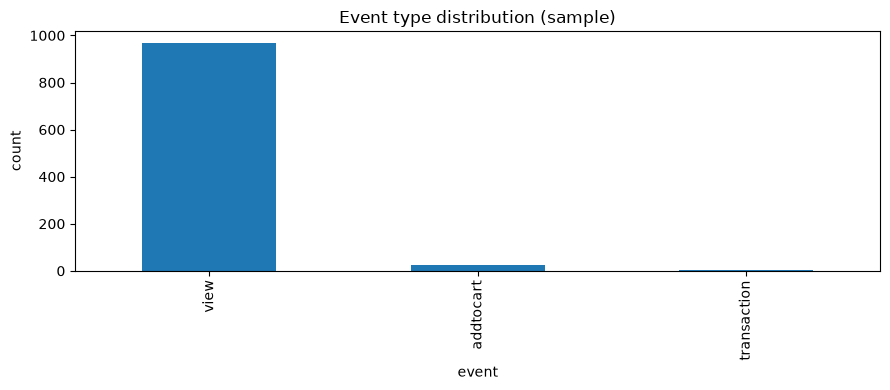

In [3]:
events["event"].value_counts().plot(kind="bar", title="Event type distribution (sample)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## 3. Timestamps — milliseconds, not seconds

The sample max is `1433221332117` — **13 digits = Unix milliseconds**. A seconds-based
converter would produce year 47,592 and break the ETL. Divide by 1000 first.

In [4]:
events["ts_sec"] = events["timestamp"] / 1000
events["ts_date"] = pd.to_datetime(events["ts_sec"], unit="s")
print("Range:", events["ts_date"].min(), "->", events["ts_date"].max())

Range: 2015-06-01 15:22:43.940999985 -> 2015-06-02 05:59:42.316999912


## 4. Missing values

`transactionid` is missing for non-purchase events — expected, but the ETL must handle it.

In [5]:
events.isna().sum()

timestamp          0
visitorid          0
event              0
itemid             0
transactionid    995
ts_sec             0
ts_date            0
dtype: int64

## 5. `item_properties` — a change log, not a snapshot

The same item appears **many times** as its attributes change over time.

In [6]:
props["property"].value_counts()

property
888           138
790            93
available      73
categoryid     43
6              37
             ... 
328             1
221             1
976             1
456             1
302             1
Name: count, Length: 194, dtype: int64

In [7]:
# Same item, same property, changing over time:
props[props["itemid"] == props["itemid"].iloc[0]].head(10)

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338


## 6. Hashed values — 90%+ unusable

Values look like `24214 44214 n2017.000` — hashed for privacy. Only `categoryid` and
`available` are readable, which is why the pipeline extracts **only categoryid**.

In [8]:
props["value"].sample(10, random_state=42).tolist()

['n29988.000',
 'n0.000',
 '732068 255287 446820',
 '977762',
 '769062',
 '1232090 1154859 86628',
 '166332 n2520.000 377738',
 'n12.000 628176 1267543 n1320.000 n48.000 379924 639502 1146011 664227 3078',
 '769062',
 '288796 23770']

## 7. `category_tree` — the category hierarchy

`parentid` of 0 (or null) = root category. Let's check the shape and depth.

In [9]:
cats.head()

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [10]:
print("Total categories:", len(cats))
print("Root categories (no parent):", (cats["parentid"].isna()).sum())

Total categories: 1000
Root categories (no parent): 4


## Key takeaways for the pipeline

1. **Timestamps are milliseconds** — `ts/1000` before any date conversion.
2. **`item_properties` is a change log** — dedupe to *latest value per item per property*
   (`max(timestamp)` per item) before joining; categoryid is the only useful property.
3. **`transactionid` is nullable** — only present on `transaction` events.
4. **Event types**: view dominates; transaction is the rarest (typical e-commerce).